# Head-direction cells in mouse postsubiculum (DANDI:000939)

A head-direction (HD) cell fires whenever the animal's head points in one
particular direction in the horizontal plane, independently of where the animal
is or what it is doing. This notebook demonstrates the phenomenon end to end on
real data from the DANDI Archive, and then goes past the single-cell tuning
curve to the population-level properties that make the head-direction system
an attractor network rather than a collection of independent sensory cells.

**Dataset.** [DANDI:000939](https://dandiarchive.org/dandiset/000939),
"Large-scale recordings of head direction cells in mouse postsubiculum"
(Duszkiewicz, Peyrache and colleagues). Each session is a 64-channel silicon
probe recording from mouse postsubiculum (PoSub) with three behavioural blocks:
home-cage sleep, free foraging in a square arena, and free foraging in a
triangular arena. Head direction is tracked at 100 Hz and stored as an NWB
`CompassDirection` series, and the NWB files also carry the authors' own
sleep-state scoring and their own `is_head_direction` unit label, which we use
as an independent check on our classification.

The NWB files are 20-30 GB each because they contain the raw broadband traces.
We never touch those. Everything here is streamed with `remfile` + a local disk
cache, and only the spike times, head-direction series, position and interval
tables (a few tens of MB per session) are ever read.

**What the analysis shows**

1. Individual postsubicular neurons have sharp, unimodal tuning to head direction.
2. The tuning is far stronger than a circular-shift null, and it is stable
   within a session.
3. The population tiles all directions uniformly, and the whole map rotates
   rigidly when the animal is moved to a different arena, which is what makes
   it a coherent internal compass rather than a set of independent detectors.
4. Head direction can be decoded from the population to within about 9 degrees.
5. The correlation structure that reflects the ring is still present during
   REM and non-REM sleep, when no directional sensory input exists.
6. A Poisson GLM with head direction as the only covariate predicts held-out
   spiking of HD cells well (median held-out pseudo-R² ≈ 0.31), and non-HD cells
   not at all.

Analysis is done in [Pynapple](https://pynapple.org); the encoding model uses
[NeMoS](https://nemos.readthedocs.io).

## 1. Setup

In [1]:
import json
import os
import pickle

import matplotlib
matplotlib.use("Agg")  # headless: figures are written to disk, never shown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import requests
from scipy.ndimage import gaussian_filter1d
from tqdm.auto import tqdm

plt.rcParams.update({"font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
HDC, OTH = "#c0392b", "#7f8c8d"   # colours for HD cells / everything else


def save_fig(fig, path):
    """Save a figure to disk and, in a notebook, also show it inline.

    The backend is Agg so nothing is ever drawn to a screen; in a Jupyter
    kernel we re-display the saved PNG so the notebook is self-contained.
    """
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    try:
        get_ipython()  # noqa: F821 - only defined inside an IPython kernel
        from IPython.display import Image, display
    except (NameError, ImportError):
        return
    display(Image(filename=path))

DANDISET = "000939"
CACHE_DIR = "cache"          # small extracted arrays, one .npz per session
REMFILE_CACHE = "/tmp/remfile_cache"   # byte-range cache for the streamed NWB files
RESULT_DIR = "results"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# Ten sessions, one per animal, all without optogenetic manipulation.
SESSIONS = [
    "sub-A3701_ses-191119", "sub-A3702_ses-191126", "sub-A3703_ses-191215",
    "sub-A3705_ses-200306", "sub-A3706_ses-200313", "sub-A3707_ses-200317",
    "sub-A3709_ses-200601", "sub-A3710_ses-200609", "sub-A5505_ses-200831",
    "sub-A5506_ses-200914a",
]
EXAMPLE = "sub-A3701_ses-191119"

NB_BINS = 60          # head-direction bins for tuning curves (6 deg each)
N_SHUFFLE = 200       # circular shifts per unit for the null distribution
BIN_DECODE = 0.2      # s, Bayesian decoding window
BIN_GLM = 0.1         # s, GLM time bin

## 2. Streaming the data out of DANDI

`extract_session` opens the remote NWB file, pulls the handful of arrays we
need, and writes them to a local `.npz`. `load_session` turns that `.npz` into
Pynapple objects. Running the notebook a second time reads only the `.npz`.

In [2]:
def asset_url(session):
    """Resolve a session name to its DANDI download URL."""
    path = "assets_%s.json" % DANDISET
    if not os.path.exists(path):
        res = requests.get(
            "https://api.dandiarchive.org/api/dandisets/%s/versions/draft/assets/" % DANDISET,
            params={"page_size": 100},
        ).json()
        json.dump({a["path"].split("/")[-1].replace(".nwb", ""): a["asset_id"]
                   for a in res["results"]}, open(path, "w"), indent=1)
    m = json.load(open(path))
    key, = [k for k in m if k.startswith(session)]
    return ("https://api.dandiarchive.org/api/dandisets/%s/versions/draft/assets/%s/download/"
            % (DANDISET, m[key]))


def extract_session(session, force=False):
    """Stream one NWB file and cache the arrays we need locally."""
    npz = os.path.join(CACHE_DIR, "%s.npz" % session)
    if os.path.exists(npz) and not force:
        return npz

    import h5py
    import remfile
    from pynwb import NWBHDF5IO

    rem = remfile.File(asset_url(session), disk_cache=remfile.DiskCache(REMFILE_CACHE))
    nwbfile = NWBHDF5IO(file=h5py.File(rem, "r"), load_namespaces=True).read()

    hd_ts = nwbfile.processing["behavior"]["CompassDirection"]["head-direction"]
    pos = nwbfile.processing["behavior"]["Position"]["position"]
    spike_times = nwbfile.units["spike_times"][:]
    counts = np.array([len(s) for s in spike_times])
    ep = nwbfile.intervals["epochs"].to_dataframe()
    ss = nwbfile.intervals["sleep_states"].to_dataframe()
    elec = nwbfile.electrodes.to_dataframe()
    udf = nwbfile.units.to_dataframe()
    eidx = udf["electrode_index"].values.astype(int)

    np.savez_compressed(
        npz,
        session=session, subject=nwbfile.subject.subject_id,
        spikes_flat=np.concatenate(spike_times),
        spikes_index=np.concatenate([[0], np.cumsum(counts)]),
        is_head_direction=udf["is_head_direction"].values.astype(int),
        is_excitatory=udf["is_excitatory"].values.astype(int),
        is_fast_spiking=udf["is_fast_spiking"].values.astype(int),
        trough_to_peak=udf["trough_to_peak"].values.astype(float),
        unit_depth=elec["rel_y"].values[eidx],
        hd=np.asarray(hd_ts.data[:], dtype=float),
        hd_t=np.asarray(hd_ts.timestamps[:], dtype=float),
        pos=np.asarray(pos.data[:], dtype=float),
        pos_t=np.asarray(pos.timestamps[:], dtype=float),
        ep_start=ep["start_time"].values, ep_stop=ep["stop_time"].values,
        ep_tag=np.array([t[0] for t in ep["tags"].values]),
        ss_start=ss["start_time"].values.astype(float),
        ss_stop=ss["stop_time"].values.astype(float),
        ss_state=ss["state"].values.astype(str),
        location=str(elec["location"].iloc[0]),
    )
    return npz


def _intervals(starts, stops, labels):
    out = {}
    for s, e, k in zip(starts, stops, labels):
        out.setdefault(str(k), []).append((s, e))
    return {k: nap.IntervalSet(start=[a for a, _ in v], end=[b for _, b in v])
            for k, v in out.items()}


def load_session(session):
    """Return a dict of Pynapple objects for one session."""
    d = np.load(extract_session(session), allow_pickle=False)
    flat, idx = d["spikes_flat"], d["spikes_index"]
    units = nap.TsGroup(
        {i: nap.Ts(flat[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)},
        metadata={
            "is_hd_author": d["is_head_direction"].astype(bool),
            "is_excitatory": d["is_excitatory"].astype(bool),
            "is_fast_spiking": d["is_fast_spiking"].astype(bool),
            "trough_to_peak": d["trough_to_peak"],
            "depth_um": d["unit_depth"],
        },
    )
    return dict(
        session=session, subject=str(d["subject"]), location=str(d["location"]),
        units=units,
        hd=nap.Tsd(t=d["hd_t"], d=d["hd"]),
        position=nap.TsdFrame(t=d["pos_t"], d=d["pos"], columns=["x", "y"]),
        epochs=_intervals(d["ep_start"], d["ep_stop"], d["ep_tag"]),
        states=_intervals(d["ss_start"], d["ss_stop"], d["ss_state"]),
    )

In [3]:
for s in tqdm(SESSIONS, desc="streaming from DANDI"):
    extract_session(s)

data = load_session(EXAMPLE)
print("session   :", data["session"], "| subject", data["subject"],
      "| recording site", data["location"])
print("units     :", len(data["units"]))
print("epochs    :", {k: "%.0f s" % v.tot_length() for k, v in data["epochs"].items()})
print("sleep     :", {k: "%.0f s" % v.tot_length() for k, v in data["states"].items()})
print("head dir. : %d samples at %.0f Hz, %.1f%% untracked"
      % (len(data["hd"]), 1 / np.median(np.diff(data["hd"].t)),
         100 * np.isnan(data["hd"].values).mean()))
print(data["units"][list(range(6))])

streaming from DANDI:   0%|          | 0/10 [00:00<?, ?it/s]

session   : sub-A3701_ses-191119 | subject A3701 | recording site Postsubiculum
units     : 102
epochs    : {'home_cage': '9163 s', 'wake_square': '2541 s', 'wake_triangle': '2415 s'}
sleep     : {'wake': '5147 s', 'nrem': '8481 s', 'rem': '308 s'}
head dir. : 494315 samples at 100 Hz, 0.7% untracked
  Index      rate  is_hd_author    is_excitatory    is_fast_spiking      trough_to_peak    depth_um
-------  --------  --------------  ---------------  -----------------  ----------------  ----------
      0  42.0515   False           False            True                           0.19       687.5
      1   0.88382  False           False            False                        nan          787.5
      2   0.62104  True            True             False                          0.46       512.5
      3   1.10552  False           False            False                        nan          787.5
      4   0.6243   False           False            False                          0.23       337.

## 3. Measuring directional tuning

A tuning curve is the mean firing rate of a unit as a function of head
direction: spikes per bin divided by seconds spent in that bin. We summarise
each curve with three numbers.

* **Mean vector length** (`r`, also called the Rayleigh vector) is the length of
  the circular mean of the tuning curve. It is 0 for a flat curve and approaches
  1 for a curve concentrated at a single direction.
* **Directional information**, the circular version of the Skaggs spatial
  information, in bits per spike.
* **Tuning width**, the full width at half maximum.

`FastTuning` below precomputes the bin assignment of every tracking sample so
that a tuning curve costs one `searchsorted` and one `bincount`. That matters
because the null distribution needs 200 curves per unit. It reproduces
`nap.compute_tuning_curves` (we check this explicitly further down); the small
residual difference is that `FastTuning` discards spikes that fall inside a
tracking gap instead of assigning them to the nearest tracked sample.

In [4]:
class FastTuning:
    """Precomputed head-direction binning, for cheap repeated tuning curves."""

    def __init__(self, hd, ep, nb_bins=NB_BINS):
        h = hd.restrict(ep)
        t, v = h.times(), h.values
        ok = ~np.isnan(v)
        self.t, v = t[ok], v[ok]
        self.nb_bins = nb_bins
        self.edges = np.linspace(0, 2 * np.pi, nb_bins + 1)
        self.centers = 0.5 * (self.edges[:-1] + self.edges[1:])
        self.bin_of_sample = np.clip(np.digitize(v, self.edges) - 1, 0, nb_bins - 1)
        self.dt = float(np.median(np.diff(self.t)))
        self.occupancy = np.bincount(self.bin_of_sample, minlength=nb_bins) * self.dt

    def curve(self, spike_times):
        s = np.asarray(spike_times)
        s = s[(s >= self.t[0]) & (s <= self.t[-1])]
        if s.size == 0:
            return np.zeros(self.nb_bins)
        i = np.clip(np.searchsorted(self.t, s), 1, len(self.t) - 1)
        i = np.where(np.abs(s - self.t[i - 1]) < np.abs(self.t[i] - s), i - 1, i)
        i = i[np.abs(s - self.t[i]) < 5 * self.dt]   # drop spikes in tracking gaps
        cnt = np.bincount(self.bin_of_sample[i], minlength=self.nb_bins)
        with np.errstate(divide="ignore", invalid="ignore"):
            return np.where(self.occupancy > 0, cnt / self.occupancy, 0.0)


def circular_mean_vector(bin_centers, rates):
    """Length and angle of the mean resultant vector of a circular tuning curve."""
    rates = np.asarray(rates, dtype=float)
    if rates.sum() <= 0:
        return 0.0, np.nan
    z = np.sum(rates * np.exp(1j * bin_centers)) / rates.sum()
    return float(np.abs(z)), float(np.mod(np.angle(z), 2 * np.pi))


def hd_information(rates, occupancy):
    """Skaggs information in bits/spike, applied to the directional dimension."""
    rates = np.asarray(rates, dtype=float)
    p = np.asarray(occupancy, dtype=float)
    p = p / p.sum()
    mean_rate = np.sum(p * rates)
    if mean_rate <= 0:
        return 0.0
    ok = rates > 0
    return float(np.sum(p[ok] * (rates[ok] / mean_rate) * np.log2(rates[ok] / mean_rate)))


def tuning_width(rates):
    """Full width at half maximum of a circular tuning curve, in radians."""
    rates = np.asarray(rates, dtype=float)
    if rates.max() <= 0:
        return np.nan
    half = 0.5 * (rates.max() + rates.min())
    rr = np.roll(rates, len(rates) // 2 - int(np.argmax(rates)))
    c = len(rr) // 2
    lo, hi = c, c
    while lo > 0 and rr[lo - 1] >= half:
        lo -= 1
    while hi < len(rr) - 1 and rr[hi + 1] >= half:
        hi += 1
    return (hi - lo + 1) * (2 * np.pi / len(rates))


def angdiff(a, b):
    """Signed circular difference wrapped to (-pi, pi]."""
    return np.mod(np.asarray(a) - np.asarray(b) + np.pi, 2 * np.pi) - np.pi


def intervals_from_mask(t, mask, max_gap=0.1):
    """Turn a boolean mask over a sampled time base into an IntervalSet."""
    tt = t[mask]
    if len(tt) < 2:
        return nap.IntervalSet([], [])
    br = np.where(np.diff(tt) > max_gap)[0]
    starts = np.concatenate([[tt[0]], tt[br + 1]])
    ends = np.concatenate([tt[br], [tt[-1]]])
    keep = ends > starts
    return nap.IntervalSet(start=starts[keep], end=ends[keep])


def circ_shift_shuffle(unit_ts, ep, rng, n_shuffles=N_SHUFFLE):
    """Circularly time-shifted copies of a spike train within an epoch.

    Shifting preserves each cell's firing rate and burst structure while
    destroying its relationship to head direction, which is the standard null
    hypothesis for directional tuning.
    """
    t = unit_ts.restrict(ep).times()
    starts, ends = ep.start, ep.end
    durs = ends - starts
    total = durs.sum()
    offs = np.concatenate([[0], np.cumsum(durs)])
    seg = np.clip(np.searchsorted(ends, t, side="left"), 0, len(starts) - 1)
    tc = t - starts[seg] + offs[seg]
    for _ in range(n_shuffles):
        ts = np.mod(tc + rng.uniform(0.1 * total, 0.9 * total), total)
        seg2 = np.clip(np.searchsorted(offs, ts, side="right") - 1, 0, len(starts) - 1)
        yield np.sort(ts - offs[seg2] + starts[seg2])

### Check `FastTuning` against Pynapple

In [5]:
_hd, _units = data["hd"], data["units"]
_sq = data["epochs"]["wake_square"]
_ft = FastTuning(_hd, _sq)
_tc_nap = nap.compute_tuning_curves(_units, _hd, bins=NB_BINS,
                                    range=[(0, 2 * np.pi)], epochs=_sq).to_pandas().T
_a = np.concatenate([_tc_nap[c].values for c in _tc_nap.columns])
_b = np.concatenate([_ft.curve(_units[c].t) for c in _tc_nap.columns])
print("FastTuning vs nap.compute_tuning_curves: r = %.6f over %d (unit, bin) values"
      % (np.corrcoef(_a, _b)[0, 1], len(_a)))

FastTuning vs nap.compute_tuning_curves: r = 0.999820 over 6120 (unit, bin) values


## 4. The per-session analysis

`analyse_session` runs the whole pipeline for one animal: tuning curves and
their summary statistics, the shuffle null and the HD classification,
split-half stability, the same cells in the second arena, cross-validated
Bayesian decoding, and the pairwise correlation structure in each brain state.
Results for all ten animals are cached in `results/all_sessions.pkl`.

In [6]:
def analyse_session(session, seed=0):
    """Full per-session analysis. Returns a dict of results."""
    d = load_session(session)
    hd, units = d["hd"], d["units"]
    sq = d["epochs"]["wake_square"]
    rng = np.random.default_rng(seed)

    ft = FastTuning(hd, sq)
    C = ft.centers
    tc = np.array([ft.curve(units[c].t) for c in units.keys()])
    mvl = np.zeros(len(tc)); pref = np.zeros(len(tc)); info = np.zeros(len(tc))
    for i, curve in enumerate(tc):
        mvl[i], pref[i] = circular_mean_vector(C, curve)
        info[i] = hd_information(curve, ft.occupancy)
    width = np.array([tuning_width(curve) for curve in tc])

    # circular-shift null
    null = np.zeros((len(tc), N_SHUFFLE))
    for i, c in enumerate(units.keys()):
        for j, s in enumerate(circ_shift_shuffle(units[c], sq, rng)):
            null[i, j] = circular_mean_vector(C, ft.curve(s))[0]
    p_cell = (1 + (null >= mvl[:, None]).sum(1)) / (N_SHUFFLE + 1)
    thr = float(np.percentile(null.ravel(), 99))

    # split-half stability
    mid = sq.start[0] + (sq.end[0] - sq.start[0]) / 2
    e1, e2 = nap.IntervalSet(sq.start[0], mid), nap.IntervalSet(mid, sq.end[0])
    f1, f2 = FastTuning(hd, e1), FastTuning(hd, e2)
    tc1 = np.array([f1.curve(units[c].t) for c in units.keys()])
    tc2 = np.array([f2.curve(units[c].t) for c in units.keys()])
    stab = np.array([np.corrcoef(a, b)[0, 1] if a.std() > 0 and b.std() > 0 else np.nan
                     for a, b in zip(tc1, tc2)])

    is_hd = (mvl > thr) & (p_cell < 0.01) & (stab > 0.5)
    hd_idx = np.where(is_hd)[0]

    # the same cells in the second arena
    cross = None
    if "wake_triangle" in d["epochs"]:
        ftt = FastTuning(hd, d["epochs"]["wake_triangle"])
        tct = np.array([ftt.curve(units[c].t) for c in units.keys()])
        pref_t = np.array([circular_mean_vector(C, curve)[1] for curve in tct])
        z = np.mean(np.exp(1j * angdiff(pref_t[hd_idx], pref[hd_idx])))
        cross = dict(pref_tri=pref_t, dphi=angdiff(pref_t[hd_idx], pref[hd_idx]),
                     rotation=float(np.mod(np.angle(z), 2 * np.pi)), R=float(np.abs(z)))

    # control: is the tuning directional or positional? Recompute the preferred
    # direction separately in each spatial quadrant of the arena.
    pos = d["position"].restrict(sq)
    xm, ym = np.median(pos["x"].values), np.median(pos["y"].values)
    quad = {}
    for name, m in [("SW", (pos["x"].values < xm) & (pos["y"].values < ym)),
                    ("SE", (pos["x"].values >= xm) & (pos["y"].values < ym)),
                    ("NW", (pos["x"].values < xm) & (pos["y"].values >= ym)),
                    ("NE", (pos["x"].values >= xm) & (pos["y"].values >= ym))]:
        fq = FastTuning(hd, intervals_from_mask(pos.t, m))
        pq = np.array([circular_mean_vector(C, fq.curve(units[int(c)].t))[1]
                       for c in hd_idx])
        quad[name] = angdiff(pq, pref[hd_idx])

    # cross-validated Bayesian decoding: tuning curves from half 1, decode half 2
    sub = units[[int(c) for c in hd_idx]]
    tcdf = pd.DataFrame(index=C, data={int(c): f1.curve(units[int(c)].t) for c in hd_idx})
    dec, _ = nap.decode_1d(tuning_curves=tcdf, group=sub, ep=e2, bin_size=BIN_DECODE)
    true = hd.restrict(e2).interpolate(dec)
    derr = np.degrees(np.abs(angdiff(dec.values, true.values)))
    derr = derr[~np.isnan(derr)]

    decode_vs_n = []
    for n in [2, 5, 10, 20, 40, 80]:
        if n > len(hd_idx):
            break
        pick = np.sort(rng.permutation(hd_idx)[:n])
        tcn = pd.DataFrame(index=C, data={int(c): f1.curve(units[int(c)].t) for c in pick})
        dn, _ = nap.decode_1d(tuning_curves=tcn, group=units[[int(c) for c in pick]],
                              ep=e2, bin_size=BIN_DECODE)
        tn = hd.restrict(e2).interpolate(dn)
        decode_vs_n.append((n, float(np.nanmedian(
            np.degrees(np.abs(angdiff(dn.values, tn.values)))))))

    # pairwise correlations of the HD ensemble, by brain state
    home = d["epochs"]["home_cage"]
    empty = nap.IntervalSet([], [])
    iu = np.triu_indices(len(hd_idx), 1)
    pw = {}
    for name, ep, bs in [("wake", sq, 0.5),
                         ("REM", d["states"].get("rem", empty).intersect(home), 0.5),
                         ("nREM", d["states"].get("nrem", empty).intersect(home), 0.1)]:
        if ep.tot_length() < 100:
            pw[name] = None
            continue
        z = np.asarray(sub.count(bs, ep).values, dtype=float)
        pw[name] = np.corrcoef(z.T)[iu]

    return dict(
        session=session, subject=d["subject"], centers=C,
        tc=tc, tc1=tc1, tc2=tc2, occupancy=ft.occupancy,
        mvl=mvl, pref=pref, info=info, width=width, stab=stab,
        p_cell=p_cell, null=null, thr=thr, is_hd=is_hd,
        rates=np.array([units.rates[c] for c in units.keys()]),
        is_hd_author=units.metadata["is_hd_author"].values,
        is_excitatory=units.metadata["is_excitatory"].values,
        is_fast_spiking=units.metadata["is_fast_spiking"].values,
        cross=cross, quad=quad, decode_err=derr, decode_vs_n=decode_vs_n,
        pw=pw, pw_offsets=np.abs(angdiff(pref[hd_idx][:, None], pref[hd_idx][None, :]))[iu],
    )


_cached = os.path.join(RESULT_DIR, "all_sessions.pkl")
if os.path.exists(_cached):
    R = pickle.load(open(_cached, "rb"))
else:
    R = {}
    for s in tqdm(SESSIONS, desc="analysing"):
        R[s] = analyse_session(s)
    pickle.dump(R, open(_cached, "wb"))

r = R[EXAMPLE]
C = r["centers"]
hd_idx = np.where(r["is_hd"])[0]
order = hd_idx[np.argsort(r["pref"][hd_idx])]
print("%s: %d units, %d classified as HD cells" % (EXAMPLE, len(r["mvl"]), r["is_hd"].sum()))

sub-A3701_ses-191119: 102 units, 77 classified as HD cells


## 5. Raw data

Forty seconds of the square-arena block. The bottom panel is a raster of the
cells classified as HD cells, sorted by preferred direction, with the tracked
head direction overlaid in black. The spiking follows the head direction: as
the animal turns, the active band of cells sweeps through the sorted
population.

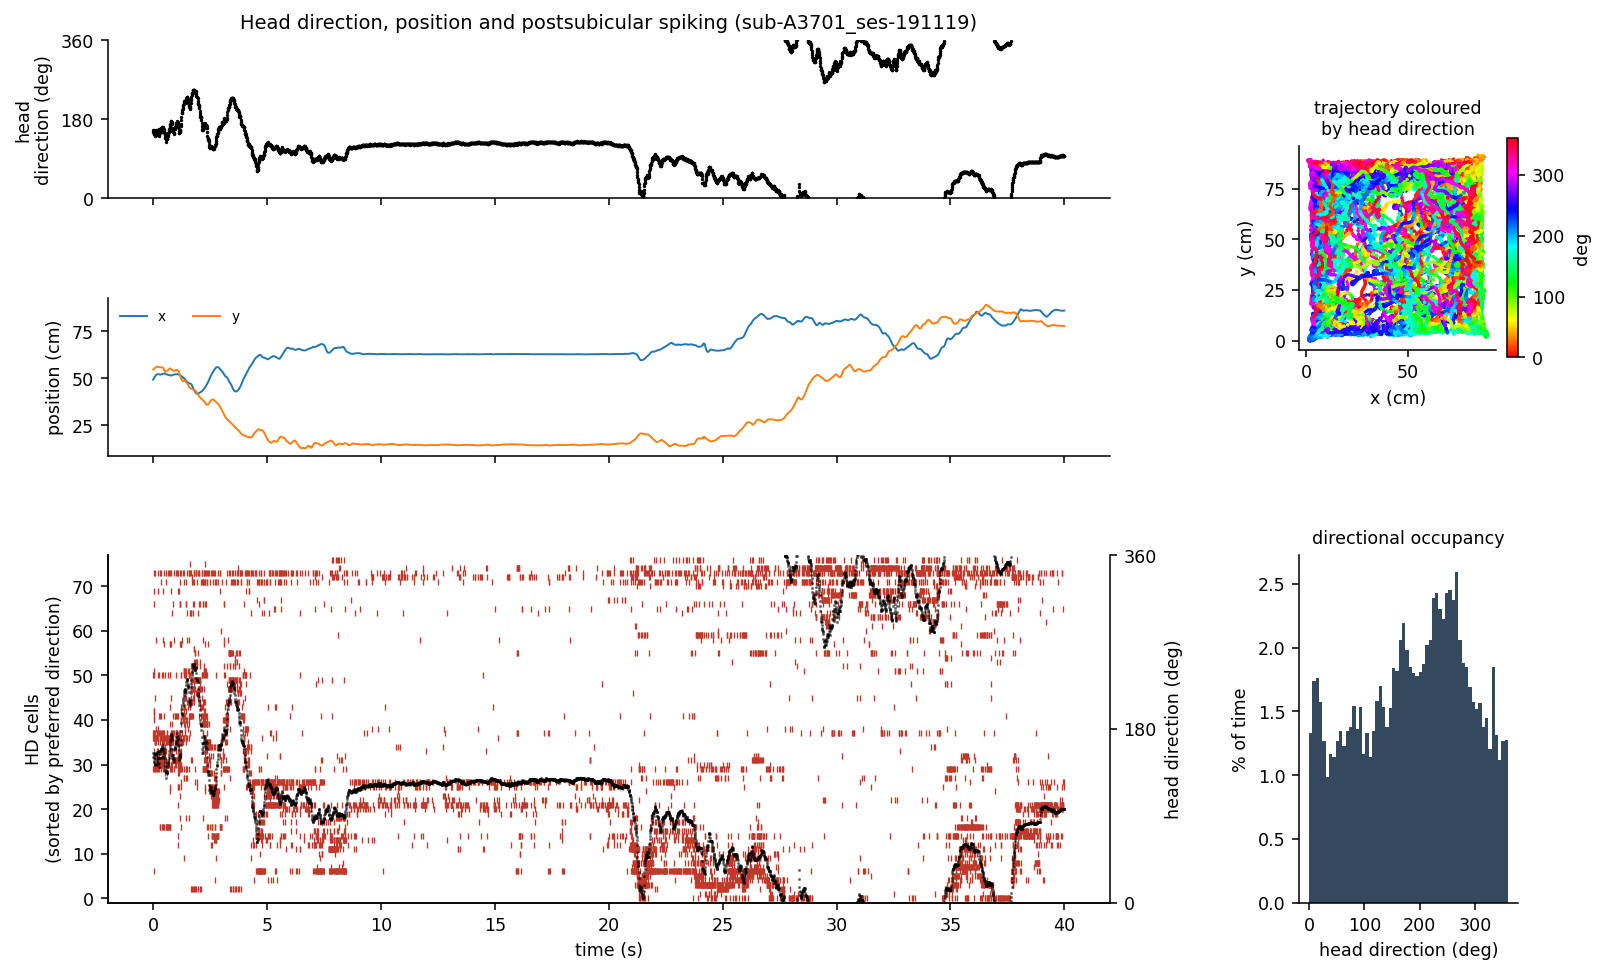

In [7]:
hd, units, sq = data["hd"], data["units"], data["epochs"]["wake_square"]

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 2.2], width_ratios=[2.6, 2.6, 1.4],
                      hspace=0.45, wspace=0.55)
t0 = sq.start[0] + 600
win = nap.IntervalSet(t0, t0 + 40)

ax = fig.add_subplot(gs[0, :2])
h = hd.restrict(win)
ax.plot(h.t - t0, np.degrees(h.values), "k.", ms=1.5)
ax.set_ylabel("head\ndirection (deg)"); ax.set_ylim(0, 360); ax.set_yticks([0, 180, 360])
ax.set_title("Head direction, position and postsubicular spiking (%s)" % EXAMPLE, fontsize=10)
ax.set_xticklabels([])

ax = fig.add_subplot(gs[1, :2])
p = data["position"].restrict(win)
ax.plot(p.t - t0, p["x"].values, lw=1, label="x")
ax.plot(p.t - t0, p["y"].values, lw=1, label="y")
ax.set_ylabel("position (cm)"); ax.legend(fontsize=7, ncol=2, frameon=False)
ax.set_xticklabels([])

ax = fig.add_subplot(gs[2, :2])
for k, u in enumerate(order):
    ts = units[int(u)].restrict(win).t - t0
    ax.plot(ts, np.full_like(ts, k), "|", ms=3.5, color=HDC, mew=0.7)
ax.set_ylabel("HD cells\n(sorted by preferred direction)")
ax.set_xlabel("time (s)"); ax.set_ylim(-1, len(order))
axr = ax.twinx()
axr.plot(h.t - t0, np.degrees(h.values), "k.", ms=1.2, alpha=0.5)
axr.set_ylim(0, 360); axr.set_yticks([0, 180, 360]); axr.set_ylabel("head direction (deg)")
axr.spines["right"].set_visible(True)

ax = fig.add_subplot(gs[:2, 2])
pos_sq = data["position"].restrict(sq)
hdi = hd.restrict(sq).interpolate(pos_sq)
sc = ax.scatter(pos_sq["x"].values[::5], pos_sq["y"].values[::5],
                c=np.degrees(hdi.values[::5]), cmap="hsv", s=0.7, vmin=0, vmax=360)
ax.set_aspect("equal"); ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)")
ax.set_title("trajectory coloured\nby head direction", fontsize=9)
plt.colorbar(sc, ax=ax, label="deg", fraction=0.05)

ax = fig.add_subplot(gs[2, 2])
ax.bar(np.degrees(C), 100 * r["occupancy"] / r["occupancy"].sum(),
       width=360 / NB_BINS, color="#34495e")
ax.set_xlabel("head direction (deg)"); ax.set_ylabel("% of time")
ax.set_title("directional occupancy", fontsize=9)
save_fig(fig, "fig01_raw_data.png")

## 6. Single-cell tuning curves

Eight of the most strongly tuned units and, in the bottom row, four units with
no directional tuning. Dashed and dotted curves are the first and second half
of the same session, computed independently; for the HD cells they lie almost
on top of each other. Note the firing rates: HD cells here are low-rate
(< 5 Hz mean) with a sharp peak, while the untuned units include high-rate
fast-spiking cells.

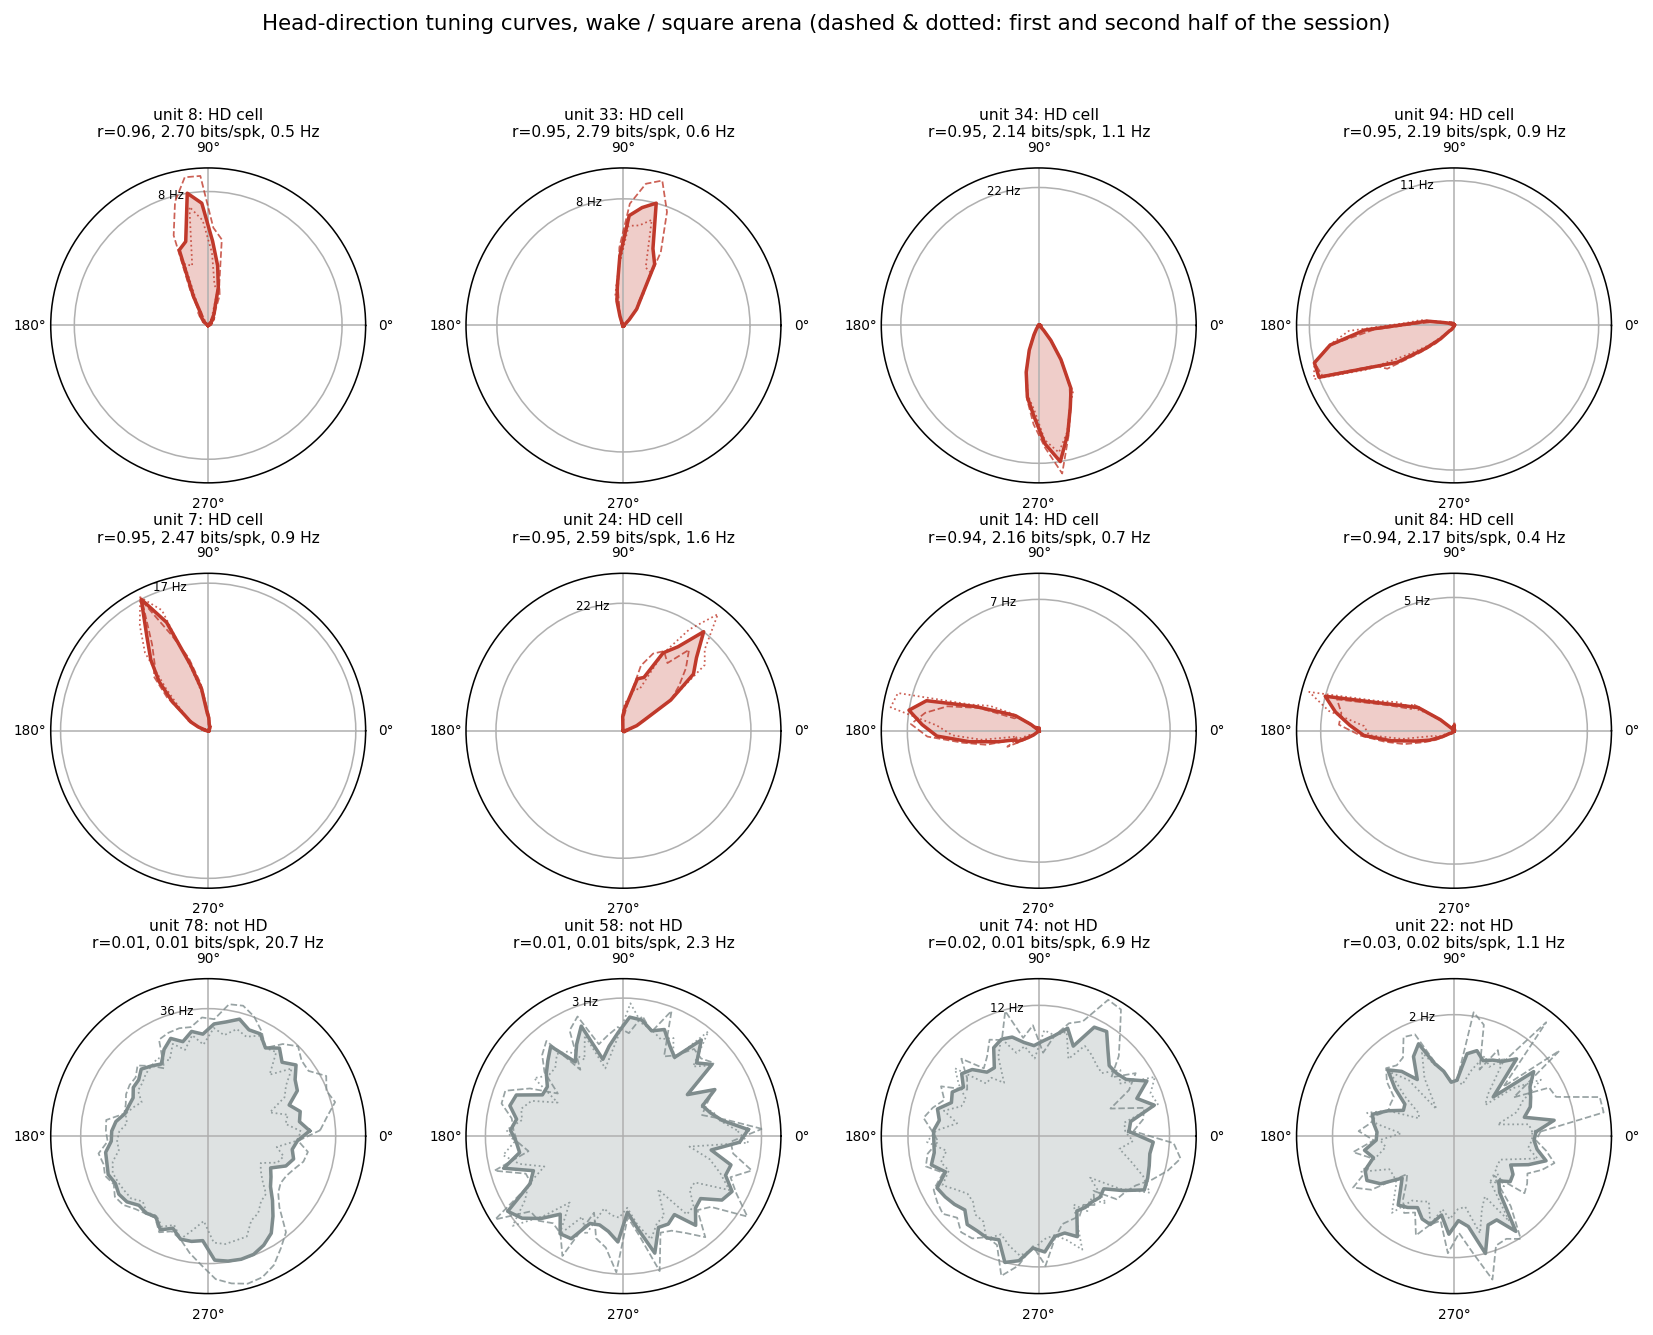

In [8]:
best = hd_idx[np.argsort(-r["mvl"][hd_idx])][:8]
worst = np.where(~r["is_hd"])[0]
worst = worst[np.argsort(r["mvl"][worst])][:4]


def polar_close(x, y):
    return np.append(x, x[0]), np.append(y, y[0])


fig, axes = plt.subplots(3, 4, figsize=(12, 9.5), subplot_kw={"projection": "polar"})
for ax, u in zip(axes.ravel(), list(best) + list(worst)):
    col = HDC if r["is_hd"][u] else OTH
    x, y = polar_close(C, r["tc"][u])
    ax.plot(x, y, color=col, lw=1.8)
    ax.fill(x, y, color=col, alpha=0.25)
    for half, ls in [(r["tc1"][u], "--"), (r["tc2"][u], ":")]:
        ax.plot(*polar_close(C, half), ls, color=col, lw=0.9, alpha=0.8)
    ax.set_title("unit %d: %s\nr=%.2f, %.2f bits/spk, %.1f Hz"
                 % (u, "HD cell" if r["is_hd"][u] else "not HD", r["mvl"][u],
                    r["info"][u], r["rates"][u]), fontsize=8, pad=16)
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_xticklabels(["0°", "90°", "180°", "270°"], fontsize=7)
    ax.set_yticks([np.nanmax(r["tc"][u])])
    ax.set_yticklabels(["%.0f Hz" % np.nanmax(r["tc"][u])], fontsize=6)
    ax.set_rlabel_position(112)
    ax.tick_params(pad=0)
fig.suptitle("Head-direction tuning curves, wake / square arena "
             "(dashed & dotted: first and second half of the session)", fontsize=11, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "fig02_tuning_examples.png")

## 7. Is the tuning real? A circular-shift null

The concern with any tuning curve is that a slowly drifting firing rate can
look directional simply because the animal does not sample all directions
uniformly. We test against a null that keeps each cell's firing statistics but
breaks the link to behaviour: shift the whole spike train circularly within the
foraging epoch by a random amount and recompute the tuning curve, 200 times per
unit.

A cell is called an HD cell if it satisfies all three of

* mean vector length above the 99th percentile of the *pooled* null across all
  units in that session (a population-level criterion, more conservative than
  a per-cell one),
* per-cell shuffle p < 0.01,
* split-half tuning-curve correlation > 0.5.

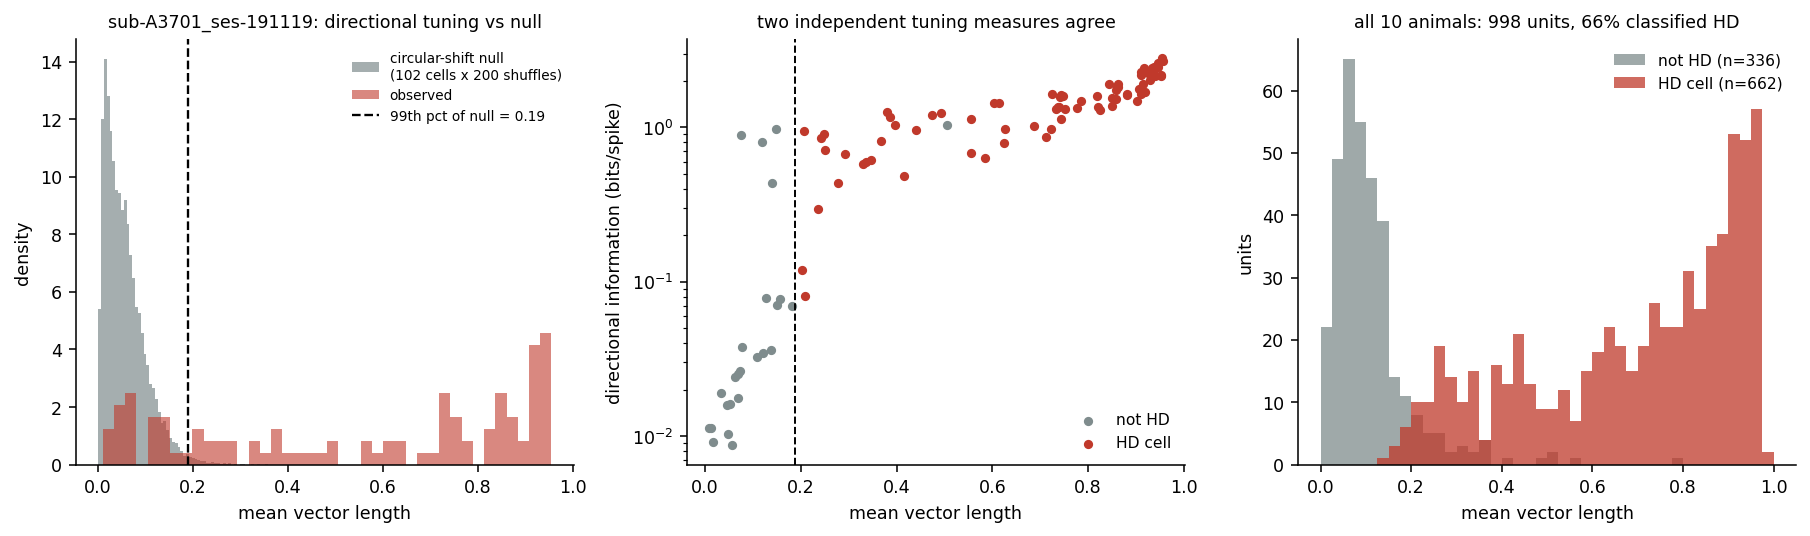

HD cells: 662 / 998 units (66%) across 10 animals
  mean vector length : HD 0.76 vs other 0.087 (medians)
  information        : HD 1.50 vs other 0.036 bits/spike
  split-half r       : HD 0.95 vs other 0.63


In [9]:
allm = np.concatenate([x["mvl"] for x in R.values()])
allh = np.concatenate([x["is_hd"] for x in R.values()])
alli = np.concatenate([x["info"] for x in R.values()])
alls = np.concatenate([x["stab"] for x in R.values()])
alla = np.concatenate([x["is_hd_author"] for x in R.values()])
allexc = np.concatenate([x["is_excitatory"] for x in R.values()])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
ax = axes[0]
ax.hist(r["null"].ravel(), bins=60, density=True, color=OTH, alpha=0.7,
        label="circular-shift null\n(%d cells x %d shuffles)" % r["null"].shape)
ax.hist(r["mvl"], bins=40, density=True, color=HDC, alpha=0.6, label="observed")
ax.axvline(r["thr"], color="k", ls="--", lw=1.2, label="99th pct of null = %.2f" % r["thr"])
ax.set_xlabel("mean vector length"); ax.set_ylabel("density")
ax.legend(fontsize=7, frameon=False)
ax.set_title("%s: directional tuning vs null" % EXAMPLE, fontsize=9)

ax = axes[1]
ax.scatter(r["mvl"][~r["is_hd"]], r["info"][~r["is_hd"]], s=14, c=OTH, label="not HD")
ax.scatter(r["mvl"][r["is_hd"]], r["info"][r["is_hd"]], s=14, c=HDC, label="HD cell")
ax.axvline(r["thr"], color="k", ls="--", lw=1)
ax.set_xlabel("mean vector length"); ax.set_ylabel("directional information (bits/spike)")
ax.set_yscale("log"); ax.legend(fontsize=8, frameon=False)
ax.set_title("two independent tuning measures agree", fontsize=9)

ax = axes[2]
bins = np.linspace(0, 1, 41)
ax.hist(allm[~allh], bins=bins, color=OTH, alpha=0.75, label="not HD (n=%d)" % (~allh).sum())
ax.hist(allm[allh], bins=bins, color=HDC, alpha=0.75, label="HD cell (n=%d)" % allh.sum())
ax.set_xlabel("mean vector length"); ax.set_ylabel("units")
ax.legend(fontsize=8, frameon=False)
ax.set_title("all 10 animals: %d units, %.0f%% classified HD"
             % (len(allm), 100 * allh.mean()), fontsize=9)
fig.tight_layout()
save_fig(fig, "fig03_significance.png")

print("HD cells: %d / %d units (%.0f%%) across %d animals"
      % (allh.sum(), len(allh), 100 * allh.mean(), len(R)))
print("  mean vector length : HD %.2f vs other %.3f (medians)"
      % (np.median(allm[allh]), np.median(allm[~allh])))
print("  information        : HD %.2f vs other %.3f bits/spike"
      % (np.median(alli[allh]), np.median(alli[~allh])))
print("  split-half r       : HD %.2f vs other %.2f"
      % (np.nanmedian(alls[allh]), np.nanmedian(alls[~allh])))

### Concordance with the labels shipped in the dataset

The NWB files carry the authors' own `is_head_direction` flag. It is a strict
subset of their `is_excitatory` flag, so units whose waveform was not
classified were never eligible for the HD label. Bearing that in mind, the two
classifications agree closely.

In [10]:
print("units labelled HD by the authors : %d" % alla.sum())
print("of those, recovered here         : %d (%.0f%%)"
      % ((allh & alla).sum(), 100 * (allh & alla).sum() / alla.sum()))
print("called HD here but not by authors: %d, of which %d are units the authors"
      % ((allh & ~alla).sum(), (allh & ~alla & ~allexc).sum()))
print("   left unclassified by waveform (and therefore ineligible for their label)")
print("overall label agreement          : %.1f%%" % (100 * np.mean(allh == alla)))

units labelled HD by the authors : 621
of those, recovered here         : 578 (93%)
called HD here but not by authors: 84, of which 76 are units the authors
   left unclassified by waveform (and therefore ineligible for their label)
overall label agreement          : 87.3%


## 8. Stability within a session and across environments

Directional tuning is not a transient response to whatever the animal happened
to be looking at. Tuning curves computed from the first and second halves of a
session are nearly identical for HD cells.

The stronger test is what happens when the animal is moved to a different arena
(square then triangle, with a home-cage sleep block in between). Preferred
directions do not stay fixed and they do not scatter randomly: the entire
population rotates by a common angle. The right-hand panel plots each cell's
preferred-direction change after subtracting the population's mean rotation,
and the distribution is tightly concentrated at zero. The relative geometry of
the map, which is what an attractor network maintains, is preserved even when
the map's absolute anchoring to the world changes.

The last panel is the control for the obvious confound. A cell that fired in
one corner of the arena, and whose head direction happened to be constrained
there, would produce a directional-looking tuning curve without coding
direction at all. Splitting the arena into four spatial quadrants and
recomputing each cell's preferred direction within each quadrant separately
leaves the preferred directions essentially unchanged, so the tuning is
directional rather than positional.

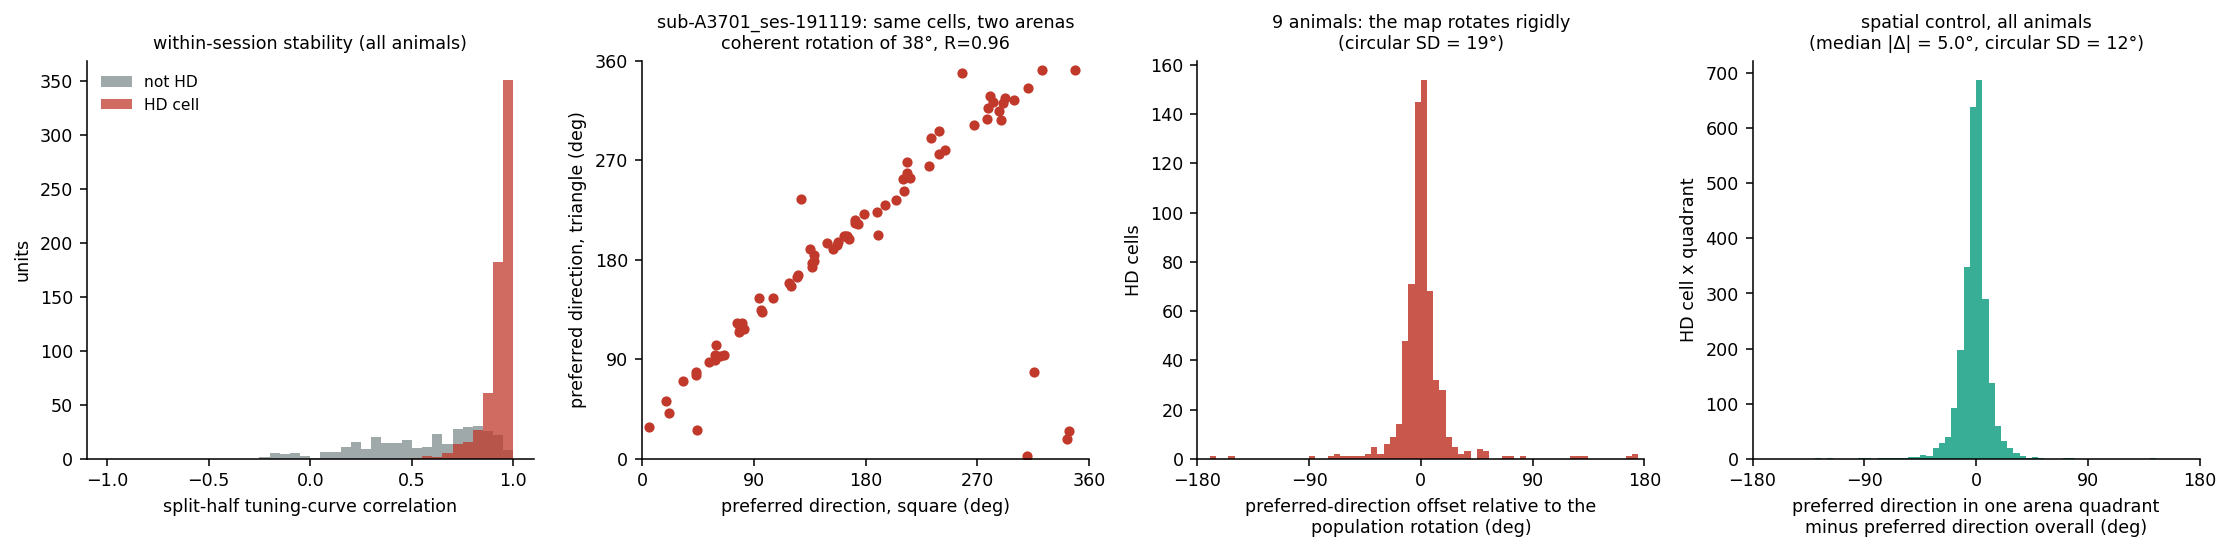

sub-A3701_ses-191119   rotation    38 deg, coherence R = 0.96
sub-A3702_ses-191126   rotation     2 deg, coherence R = 0.90
sub-A3703_ses-191215   rotation   334 deg, coherence R = 0.96
sub-A3705_ses-200306   rotation    10 deg, coherence R = 0.98
sub-A3706_ses-200313   rotation   169 deg, coherence R = 0.93
sub-A3707_ses-200317   rotation    38 deg, coherence R = 0.97
sub-A3710_ses-200609   rotation     5 deg, coherence R = 0.93
sub-A5505_ses-200831   rotation     6 deg, coherence R = 0.94
sub-A5506_ses-200914a  rotation   357 deg, coherence R = 0.89

spatial control: preferred direction recomputed within arena quadrants shifts by a median of 5.0 deg


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ax = axes[0]
ax.hist(alls[~allh], bins=np.linspace(-1, 1, 41), color=OTH, alpha=0.75, label="not HD")
ax.hist(alls[allh], bins=np.linspace(-1, 1, 41), color=HDC, alpha=0.75, label="HD cell")
ax.set_xlabel("split-half tuning-curve correlation"); ax.set_ylabel("units")
ax.legend(fontsize=8, frameon=False)
ax.set_title("within-session stability (all animals)", fontsize=9)

ax = axes[1]
cr = r["cross"]
ax.scatter(np.degrees(r["pref"][hd_idx]), np.degrees(cr["pref_tri"][hd_idx]), s=18, c=HDC)
ax.set_xlabel("preferred direction, square (deg)")
ax.set_ylabel("preferred direction, triangle (deg)")
ax.set_xlim(0, 360); ax.set_ylim(0, 360)
ax.set_xticks([0, 90, 180, 270, 360]); ax.set_yticks([0, 90, 180, 270, 360])
ax.set_title("%s: same cells, two arenas\ncoherent rotation of %.0f°, R=%.2f"
             % (EXAMPLE, np.degrees(cr["rotation"]), cr["R"]), fontsize=9)

ax = axes[2]
alld = np.degrees(angdiff(np.concatenate(
    [x["cross"]["dphi"] - x["cross"]["rotation"] for x in R.values()
     if x["cross"] is not None]), 0))
n_cross = sum(x["cross"] is not None for x in R.values())
ax.hist(alld, bins=np.linspace(-180, 180, 73), color=HDC, alpha=0.85)
ax.set_xlabel("preferred-direction offset relative to the\npopulation rotation (deg)")
ax.set_ylabel("HD cells"); ax.set_xlim(-180, 180); ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_title("%d animals: the map rotates rigidly\n(circular SD = %.0f°)"
             % (n_cross, np.degrees(np.sqrt(-2 * np.log(
                 np.abs(np.mean(np.exp(1j * np.radians(alld)))))))), fontsize=9)

ax = axes[3]
quadd = np.degrees(np.concatenate([np.concatenate(list(x["quad"].values()))
                                   for x in R.values()]))
ax.hist(quadd, bins=np.linspace(-180, 180, 73), color="#16a085", alpha=0.85)
ax.set_xlabel("preferred direction in one arena quadrant\nminus preferred direction overall (deg)")
ax.set_ylabel("HD cell x quadrant")
ax.set_xlim(-180, 180); ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_title("spatial control, all animals\n(median |Δ| = %.1f°, circular SD = %.0f°)"
             % (np.nanmedian(np.abs(quadd)),
                np.degrees(np.sqrt(-2 * np.log(
                    np.abs(np.mean(np.exp(1j * np.radians(quadd)))))))), fontsize=9)
fig.tight_layout()
save_fig(fig, "fig04_stability_crossenv.png")

for s in R:
    if R[s]["cross"] is not None:
        print("%-22s rotation %5.0f deg, coherence R = %.2f"
              % (s, np.degrees(R[s]["cross"]["rotation"]), R[s]["cross"]["R"]))
print("\nspatial control: preferred direction recomputed within arena quadrants "
      "shifts by a median of %.1f deg" % np.nanmedian(np.abs(quadd)))

## 9. The population tiles all directions

Sorting the HD cells by preferred direction and plotting their normalised
tuning curves as an image gives a clean diagonal: every direction is covered,
with no gaps and no over-representation of any particular heading. Pooled over
all ten animals the preferred directions are essentially uniform on the circle.

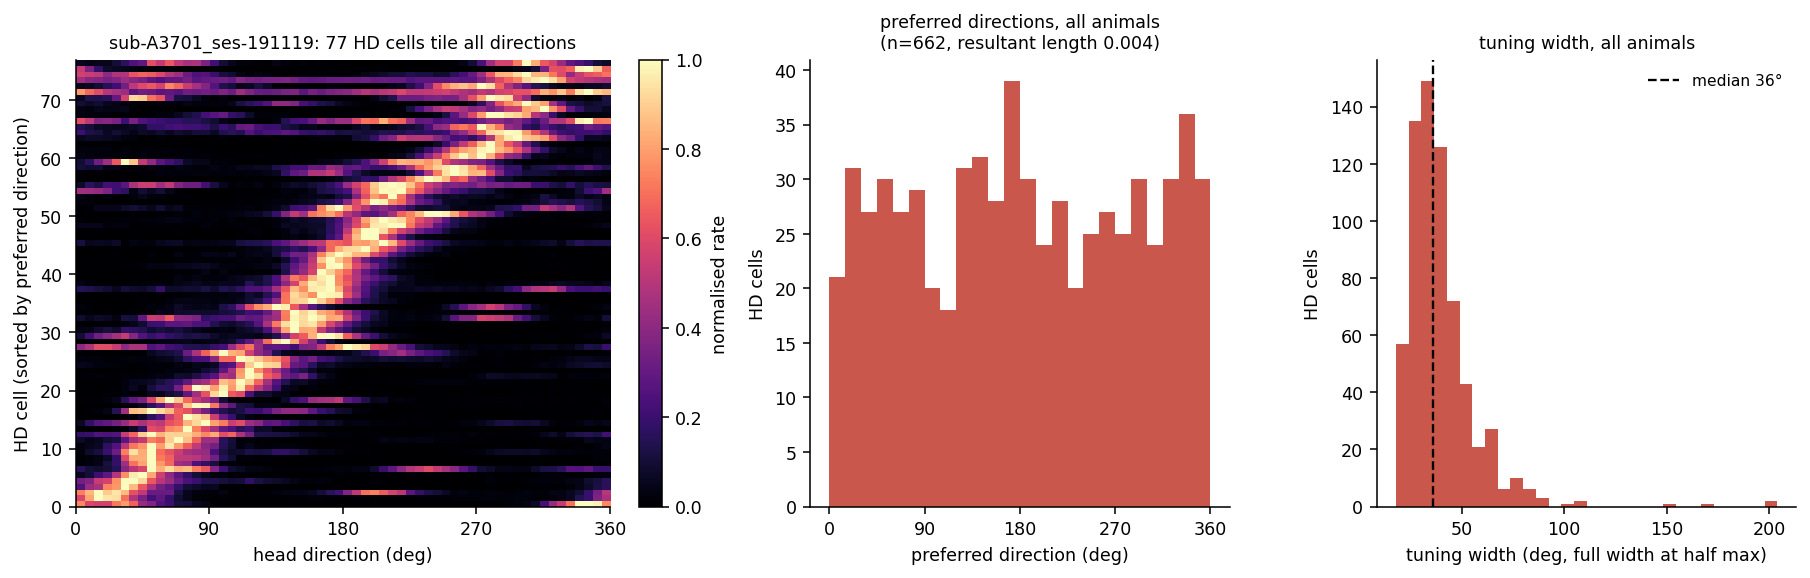

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.4, 1, 1]})
ax = axes[0]
norm = r["tc"][order] / r["tc"][order].max(1, keepdims=True)
im = ax.imshow(norm, aspect="auto", origin="lower", cmap="magma",
               extent=[0, 360, 0, len(order)])
ax.set_xlabel("head direction (deg)")
ax.set_ylabel("HD cell (sorted by preferred direction)")
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_title("%s: %d HD cells tile all directions" % (EXAMPLE, len(order)), fontsize=9)
plt.colorbar(im, ax=ax, label="normalised rate", fraction=0.04)

ax = axes[1]
allp = np.concatenate([x["pref"][x["is_hd"]] for x in R.values()])
ax.hist(np.degrees(allp), bins=np.arange(0, 361, 15), color=HDC, alpha=0.85)
ax.set_xlabel("preferred direction (deg)"); ax.set_ylabel("HD cells")
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_title("preferred directions, all animals\n(n=%d, resultant length %.3f)"
             % (len(allp), np.abs(np.mean(np.exp(1j * allp)))), fontsize=9)

ax = axes[2]
allw = np.degrees(np.concatenate([x["width"][x["is_hd"]] for x in R.values()]))
ax.hist(allw, bins=30, color=HDC, alpha=0.85)
ax.axvline(np.median(allw), color="k", ls="--", lw=1.2, label="median %.0f°" % np.median(allw))
ax.set_xlabel("tuning width (deg, full width at half max)")
ax.set_ylabel("HD cells"); ax.legend(fontsize=8, frameon=False)
ax.set_title("tuning width, all animals", fontsize=9)
fig.tight_layout()
save_fig(fig, "fig05_population_tuning.png")

## 10. Decoding head direction from the population

If the population really carries a directional signal, we should be able to
read the animal's heading out of it. We use Pynapple's Bayesian decoder in
200 ms bins, with the tuning curves estimated from the first half of the
session and the decoding done on the held-out second half, so the tuning curves
and the decoded data never share any spikes.

The top panel shows the raw ingredient: binned population activity with cells
sorted by preferred direction. The active cells form a single localised bump
that moves smoothly, and the decoded heading (green) follows the tracked
heading (white).

/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_50314/1474086736.py:6: FutureWarning: decode_1d is deprecated and will be removed in a future version; use decode_bayes instead.
  dec, _ = nap.decode_1d(tuning_curves=tc1, group=sub, ep=e2, bin_size=BIN_DECODE)


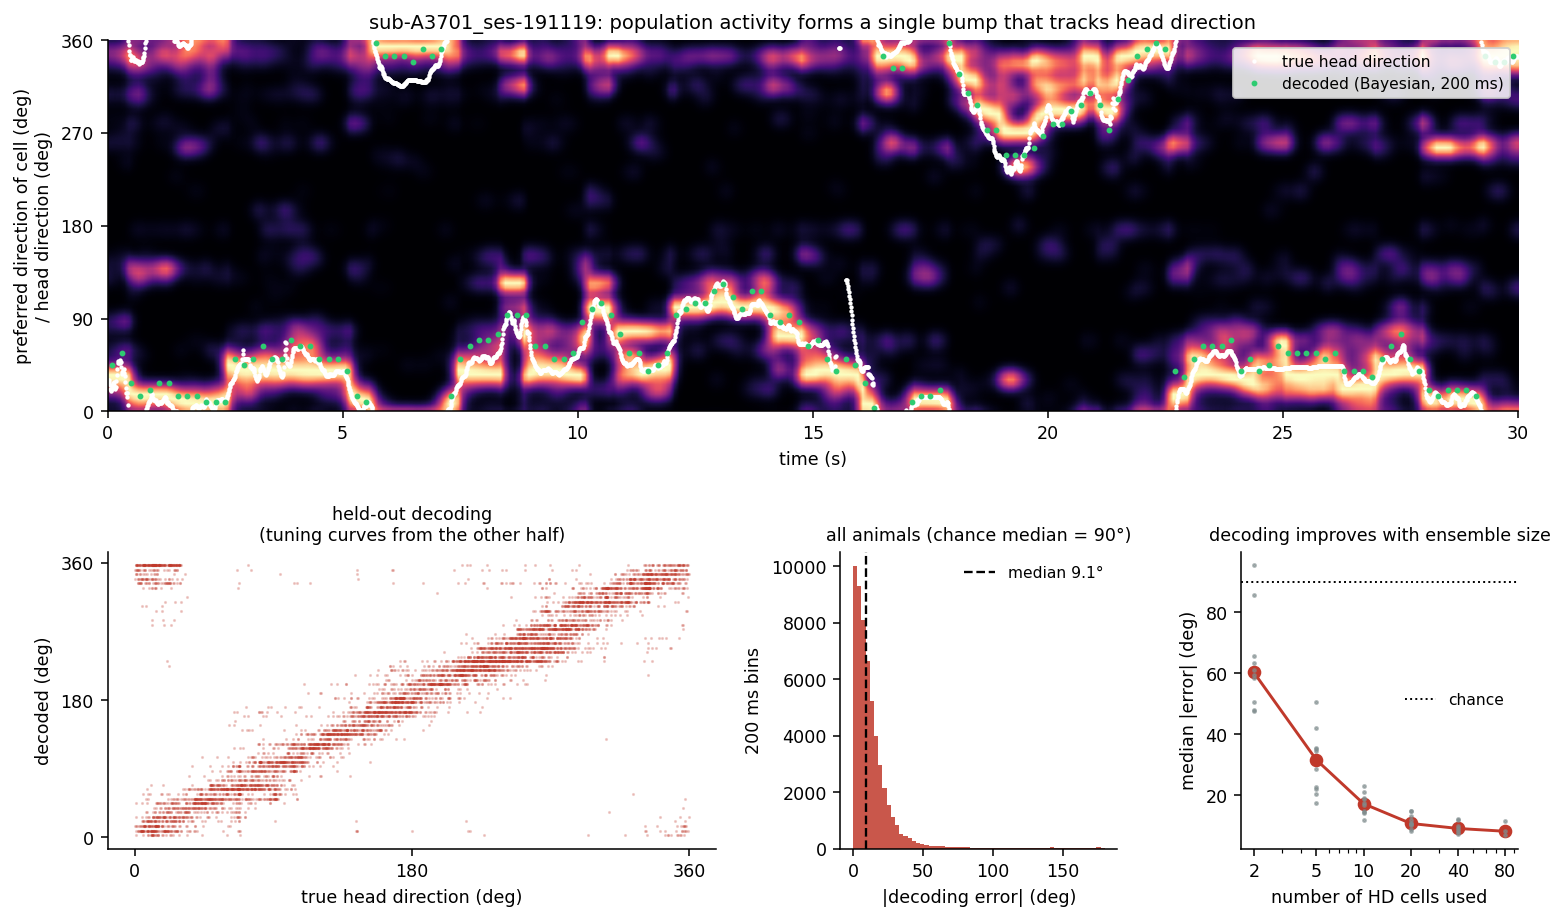

median absolute decoding error, per animal:
  sub-A3701_ses-191119   11.4 deg (77 HD cells)
  sub-A3702_ses-191126   7.7 deg (66 HD cells)
  sub-A3703_ses-191215   8.9 deg (70 HD cells)
  sub-A3705_ses-200306   8.9 deg (72 HD cells)
  sub-A3706_ses-200313   6.8 deg (92 HD cells)
  sub-A3707_ses-200317   11.2 deg (108 HD cells)
  sub-A3709_ses-200601   9.6 deg (33 HD cells)
  sub-A3710_ses-200609   8.1 deg (85 HD cells)
  sub-A5505_ses-200831   8.8 deg (35 HD cells)
  sub-A5506_ses-200914a  14.2 deg (24 HD cells)
pooled: 9.1 deg (chance 90 deg)


In [13]:
mid = sq.start[0] + (sq.end[0] - sq.start[0]) / 2
e1, e2 = nap.IntervalSet(sq.start[0], mid), nap.IntervalSet(mid, sq.end[0])
f1 = FastTuning(hd, e1)
tc1 = pd.DataFrame(index=C, data={int(c): f1.curve(units[int(c)].t) for c in hd_idx})
sub = units[[int(c) for c in hd_idx]]
dec, _ = nap.decode_1d(tuning_curves=tc1, group=sub, ep=e2, bin_size=BIN_DECODE)
true = hd.restrict(e2).interpolate(dec)

fig = plt.figure(figsize=(13, 7.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1], width_ratios=[2.2, 1, 1],
                      hspace=0.42, wspace=0.32)
t0 = e2.start[0] + 400
win = nap.IntervalSet(t0, t0 + 30)

ax = fig.add_subplot(gs[0, :])
z = np.asarray(sub.count(0.1, win).values, dtype=float)[:, np.argsort(r["pref"][hd_idx])]
# smooth for display: along time, and along the preferred-direction axis (which is
# circular, hence mode="wrap"); then scale each time bin to its own maximum
z = gaussian_filter1d(z, 1.5, axis=0)
z = gaussian_filter1d(z, 1.5, axis=1, mode="wrap")
ax.imshow((z / np.maximum(z.max(1, keepdims=True), 1e-9)).T, aspect="auto", origin="lower",
          cmap="magma", extent=[0, 30, 0, 360], interpolation="bilinear")
h = hd.restrict(win)
ax.plot(h.t - t0, np.degrees(h.values), ".", color="w", ms=2.5, label="true head direction")
dd = dec.restrict(win)
ax.plot(dd.t - t0, np.degrees(dd.values), ".", color="#2ecc71", ms=4,
        label="decoded (Bayesian, 200 ms)")
ax.set_ylabel("preferred direction of cell (deg)\n/ head direction (deg)")
ax.set_xlabel("time (s)"); ax.set_yticks([0, 90, 180, 270, 360])
ax.legend(fontsize=8, loc="upper right", framealpha=0.85)
ax.set_title("%s: population activity forms a single bump that tracks head direction"
             % EXAMPLE, fontsize=10)

ax = fig.add_subplot(gs[1, 0])
ok = ~np.isnan(true.values)
ax.plot(np.degrees(true.values[ok]), np.degrees(dec.values[ok]), ".", ms=1.2,
        color=HDC, alpha=0.25)
ax.set_xlabel("true head direction (deg)"); ax.set_ylabel("decoded (deg)")
ax.set_xticks([0, 180, 360]); ax.set_yticks([0, 180, 360])
ax.set_title("held-out decoding\n(tuning curves from the other half)", fontsize=9)

ax = fig.add_subplot(gs[1, 1])
alle = np.concatenate([x["decode_err"] for x in R.values()])
ax.hist(alle, bins=np.arange(0, 181, 3), color=HDC, alpha=0.85)
ax.axvline(np.median(alle), color="k", ls="--", lw=1.2, label="median %.1f°" % np.median(alle))
ax.set_xlabel("|decoding error| (deg)"); ax.set_ylabel("200 ms bins")
ax.legend(fontsize=8, frameon=False)
ax.set_title("all animals (chance median = 90°)", fontsize=9)

ax = fig.add_subplot(gs[1, 2])
dn = {}
for x in R.values():
    for n, e in x["decode_vs_n"]:
        dn.setdefault(n, []).append(e)
ns = sorted(dn)
ax.plot(ns, [np.median(dn[n]) for n in ns], "o-", color=HDC)
for n in ns:
    ax.plot([n] * len(dn[n]), dn[n], ".", color=OTH, ms=3, alpha=0.6)
ax.axhline(90, color="k", ls=":", lw=1, label="chance")
ax.set_xscale("log"); ax.set_xlabel("number of HD cells used")
ax.set_ylabel("median |error| (deg)")
ax.legend(fontsize=8, frameon=False, loc="center right")
ax.set_xticks(ns); ax.set_xticklabels(ns)
ax.set_title("decoding improves with ensemble size", fontsize=9)
save_fig(fig, "fig06_decoding.png")

print("median absolute decoding error, per animal:")
for s in R:
    print("  %-22s %.1f deg (%d HD cells)"
          % (s, np.median(R[s]["decode_err"]), R[s]["is_hd"].sum()))
print("pooled: %.1f deg (chance 90 deg)" % np.median(alle))

## 11. The ring survives sleep

The signature of an attractor is that the population's internal structure does
not need sensory input to exist. During sleep the animal's head is still, there
is no vestibular or visual heading signal, and yet the correlation structure of
the HD ensemble is largely unchanged: cells with similar preferred directions
still fire together and cells with opposite preferred directions still fire
apart, in both REM and non-REM sleep.

We compute pairwise spike-count correlations within the HD ensemble separately
for foraging, REM and non-REM (500 ms bins in wake and REM, 100 ms in non-REM,
where population events are faster), and compare the resulting correlation
matrices across states.

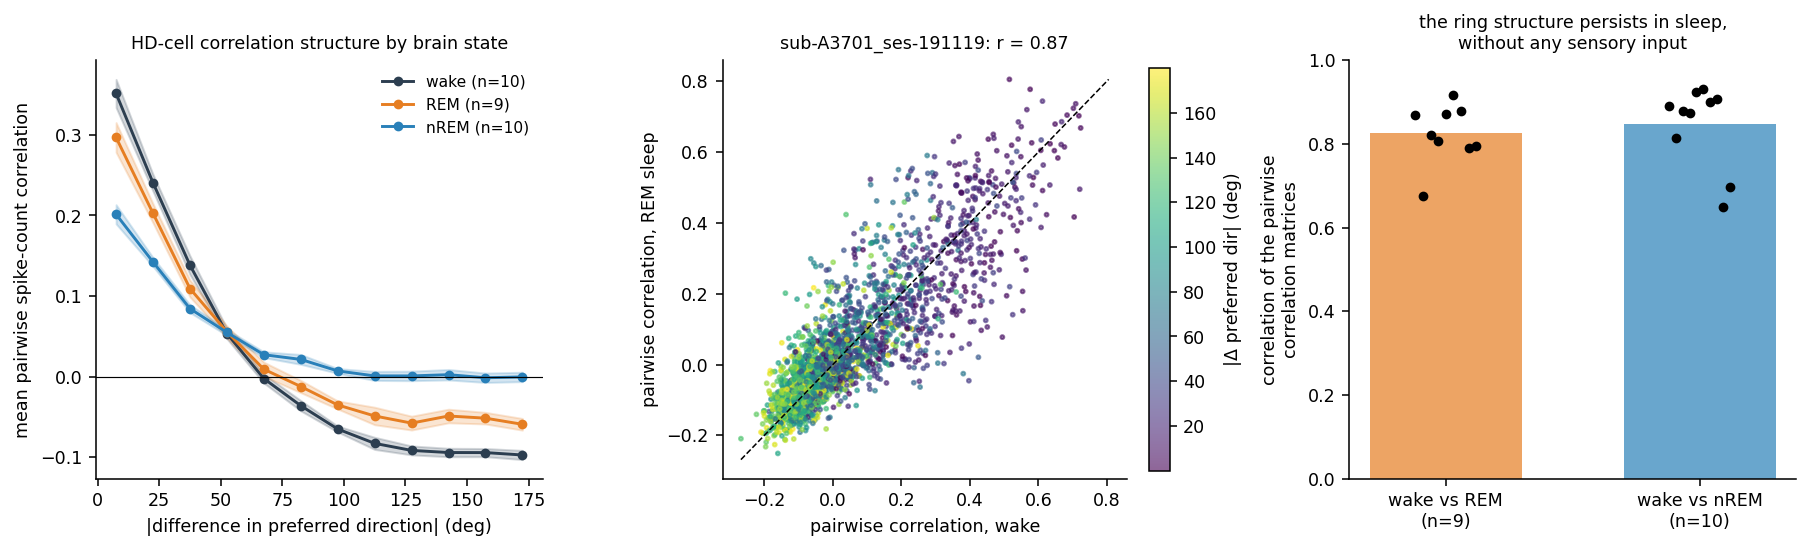

wake vs REM  correlation of correlation matrices: 0.83 +/- 0.07 (n=9 animals)
wake vs nREM correlation of correlation matrices: 0.85 +/- 0.09 (n=10 animals)


In [14]:
def offset_profile(x, key, nbin=12):
    v = x["pw"][key]
    if v is None:
        return None
    good = np.isfinite(v)
    edges = np.linspace(0, np.pi, nbin + 1)
    idx = np.clip(np.digitize(x["pw_offsets"][good], edges) - 1, 0, nbin - 1)
    return (np.array([v[good][idx == k].mean() if (idx == k).any() else np.nan
                      for k in range(nbin)]), 0.5 * (edges[:-1] + edges[1:]))


cols = {"wake": "#2c3e50", "REM": "#e67e22", "nREM": "#2980b9"}
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ax = axes[0]
for key in ["wake", "REM", "nREM"]:
    prof = [p for p in (offset_profile(x, key) for x in R.values()) if p is not None]
    Y = np.array([p[0] for p in prof]); xx = np.degrees(prof[0][1])
    m, sem = np.nanmean(Y, 0), np.nanstd(Y, 0) / np.sqrt(len(Y))
    ax.plot(xx, m, "o-", color=cols[key], label="%s (n=%d)" % (key, len(Y)), ms=4)
    ax.fill_between(xx, m - sem, m + sem, color=cols[key], alpha=0.2)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("|difference in preferred direction| (deg)")
ax.set_ylabel("mean pairwise spike-count correlation")
ax.legend(fontsize=8, frameon=False)
ax.set_title("HD-cell correlation structure by brain state", fontsize=9)

ax = axes[1]
x0, y0 = r["pw"]["wake"], r["pw"]["REM"]
g = np.isfinite(x0) & np.isfinite(y0)
sc = ax.scatter(x0[g], y0[g], s=4, c=np.degrees(r["pw_offsets"][g]), cmap="viridis", alpha=0.6)
lim = [min(x0[g].min(), y0[g].min()), max(x0[g].max(), y0[g].max())]
ax.plot(lim, lim, "k--", lw=0.8)
ax.set_xlabel("pairwise correlation, wake"); ax.set_ylabel("pairwise correlation, REM sleep")
plt.colorbar(sc, ax=ax, label="|Δ preferred dir| (deg)", fraction=0.045)
ax.set_title("%s: r = %.2f" % (EXAMPLE, np.corrcoef(x0[g], y0[g])[0, 1]), fontsize=9)

ax = axes[2]
vals = {}
for key in ["REM", "nREM"]:
    v = []
    for x in R.values():
        if x["pw"][key] is None:
            continue
        a, b = x["pw"]["wake"], x["pw"][key]
        g2 = np.isfinite(a) & np.isfinite(b)
        v.append(np.corrcoef(a[g2], b[g2])[0, 1])
    vals[key] = np.array(v)
ax.bar([0, 1], [vals["REM"].mean(), vals["nREM"].mean()],
       color=[cols["REM"], cols["nREM"]], alpha=0.7, width=0.6)
for pos, key in zip([0, 1], ["REM", "nREM"]):
    ax.plot(pos + np.linspace(-0.12, 0.12, len(vals[key])), vals[key], "ko", ms=4)
ax.set_xticks([0, 1])
ax.set_xticklabels(["wake vs REM\n(n=%d)" % len(vals["REM"]),
                    "wake vs nREM\n(n=%d)" % len(vals["nREM"])])
ax.set_ylabel("correlation of the pairwise\ncorrelation matrices")
ax.set_ylim(0, 1)
ax.set_title("the ring structure persists in sleep,\nwithout any sensory input", fontsize=9)
fig.tight_layout()
save_fig(fig, "fig07_sleep_structure.png")

print("wake vs REM  correlation of correlation matrices: %.2f +/- %.2f (n=%d animals)"
      % (vals["REM"].mean(), vals["REM"].std(), len(vals["REM"])))
print("wake vs nREM correlation of correlation matrices: %.2f +/- %.2f (n=%d animals)"
      % (vals["nREM"].mean(), vals["nREM"].std(), len(vals["nREM"])))

## 12. An encoding model: Poisson GLM with a cyclic-spline basis

The tuning curve is a descriptive statistic. To ask how much of a cell's
spiking head direction actually accounts for, we fit a Poisson GLM in which
head direction is projected onto ten cyclic B-spline basis functions (NeMoS)
and is the only covariate. The model is fit on the first half of the foraging
block and scored on the second half, so the reported McFadden pseudo-R² is a
genuine out-of-sample number.

In [15]:
import nemos as nmo


def glm_session(session):
    d = load_session(session)
    hdx, un, sqx = d["hd"], d["units"], d["epochs"]["wake_square"]
    m = sqx.start[0] + (sqx.end[0] - sqx.start[0]) / 2
    basis = nmo.basis.CyclicBSplineEval(n_basis_funcs=10, label="head_direction")
    prepared = {}
    for name, ep in [("train", nap.IntervalSet(sqx.start[0], m)),
                     ("test", nap.IntervalSet(m, sqx.end[0]))]:
        counts = un.count(BIN_GLM, ep)
        feat = hdx.bin_average(BIN_GLM, ep)
        ok = ~np.isnan(feat.values)
        prepared[name] = (np.asarray(basis.compute_features(feat.values[ok])),
                          np.asarray(counts.values)[ok])
    Xtr, ytr = prepared["train"]
    Xte, yte = prepared["test"]
    grid = np.linspace(0, 2 * np.pi, 120, endpoint=False)
    Xg = np.asarray(basis.compute_features(grid))
    r2, pred = [], []
    for i in range(ytr.shape[1]):
        mdl = nmo.glm.GLM(solver_name="LBFGS", regularizer="Ridge",
                          regularizer_strength=1e-4).fit(Xtr, ytr[:, i])
        r2.append(float(mdl.score(Xte, yte[:, i], score_type="pseudo-r2-McFadden")))
        pred.append(np.asarray(mdl.predict(Xg)) / BIN_GLM)
    return dict(pseudo_r2=np.array(r2), pred_tc=np.array(pred), grid=grid)


_glm_cache = os.path.join(RESULT_DIR, "glm.pkl")
if os.path.exists(_glm_cache):
    G = pickle.load(open(_glm_cache, "rb"))
else:
    G = {}
    for s in tqdm(SESSIONS, desc="fitting GLMs"):
        G[s] = glm_session(s)
    pickle.dump(G, open(_glm_cache, "wb"))

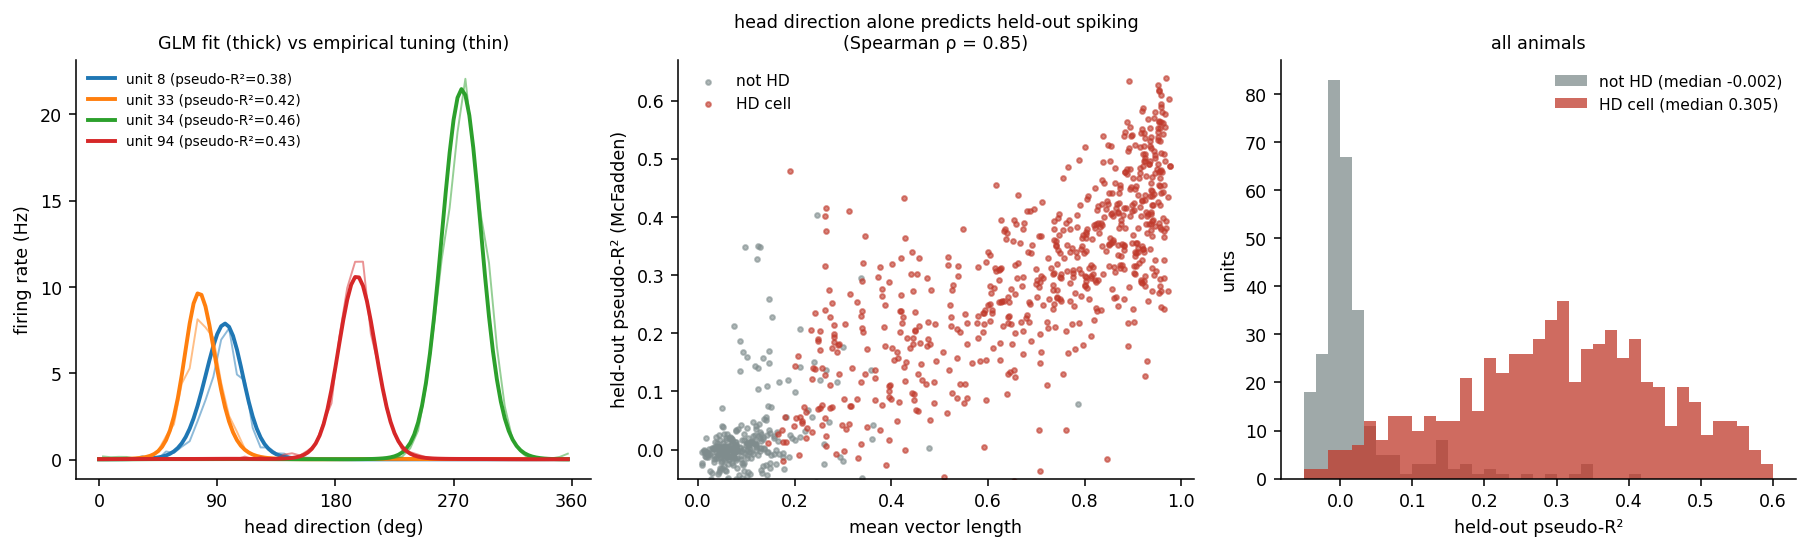

held-out pseudo-R²: HD cells 0.305, other units -0.002 (medians)


In [16]:
g = G[EXAMPLE]
allr2 = np.concatenate([G[s]["pseudo_r2"] for s in R])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ax = axes[0]
for k, u in enumerate(hd_idx[np.argsort(-r["mvl"][hd_idx])][:4]):
    ax.plot(np.degrees(C), r["tc"][u], color="C%d" % k, lw=1, alpha=0.5)
    ax.plot(np.degrees(g["grid"]), g["pred_tc"][u], color="C%d" % k, lw=2,
            label="unit %d (pseudo-R²=%.2f)" % (u, g["pseudo_r2"][u]))
ax.set_xlabel("head direction (deg)"); ax.set_ylabel("firing rate (Hz)")
ax.set_xticks([0, 90, 180, 270, 360]); ax.legend(fontsize=7, frameon=False)
ax.set_title("GLM fit (thick) vs empirical tuning (thin)", fontsize=9)

ax = axes[1]
ax.scatter(allm[~allh], allr2[~allh], s=6, c=OTH, label="not HD", alpha=0.6)
ax.scatter(allm[allh], allr2[allh], s=6, c=HDC, label="HD cell", alpha=0.6)
ax.set_ylim(-0.05, max(0.6, allr2.max() * 1.05))
ax.set_xlabel("mean vector length"); ax.set_ylabel("held-out pseudo-R² (McFadden)")
ax.legend(fontsize=8, frameon=False)
ax.set_title("head direction alone predicts held-out spiking\n(Spearman ρ = %.2f)"
             % pd.Series(allm).corr(pd.Series(allr2), method="spearman"), fontsize=9)

ax = axes[2]
b = np.linspace(-0.05, 0.6, 40)
ax.hist(allr2[~allh], bins=b, color=OTH, alpha=0.75,
        label="not HD (median %.3f)" % np.median(allr2[~allh]))
ax.hist(allr2[allh], bins=b, color=HDC, alpha=0.75,
        label="HD cell (median %.3f)" % np.median(allr2[allh]))
ax.set_xlabel("held-out pseudo-R²"); ax.set_ylabel("units")
ax.legend(fontsize=8, frameon=False)
ax.set_title("all animals", fontsize=9)
fig.tight_layout()
save_fig(fig, "fig08_glm.png")

print("held-out pseudo-R²: HD cells %.3f, other units %.3f (medians)"
      % (np.median(allr2[allh]), np.median(allr2[~allh])))

## 13. Summary across ten animals

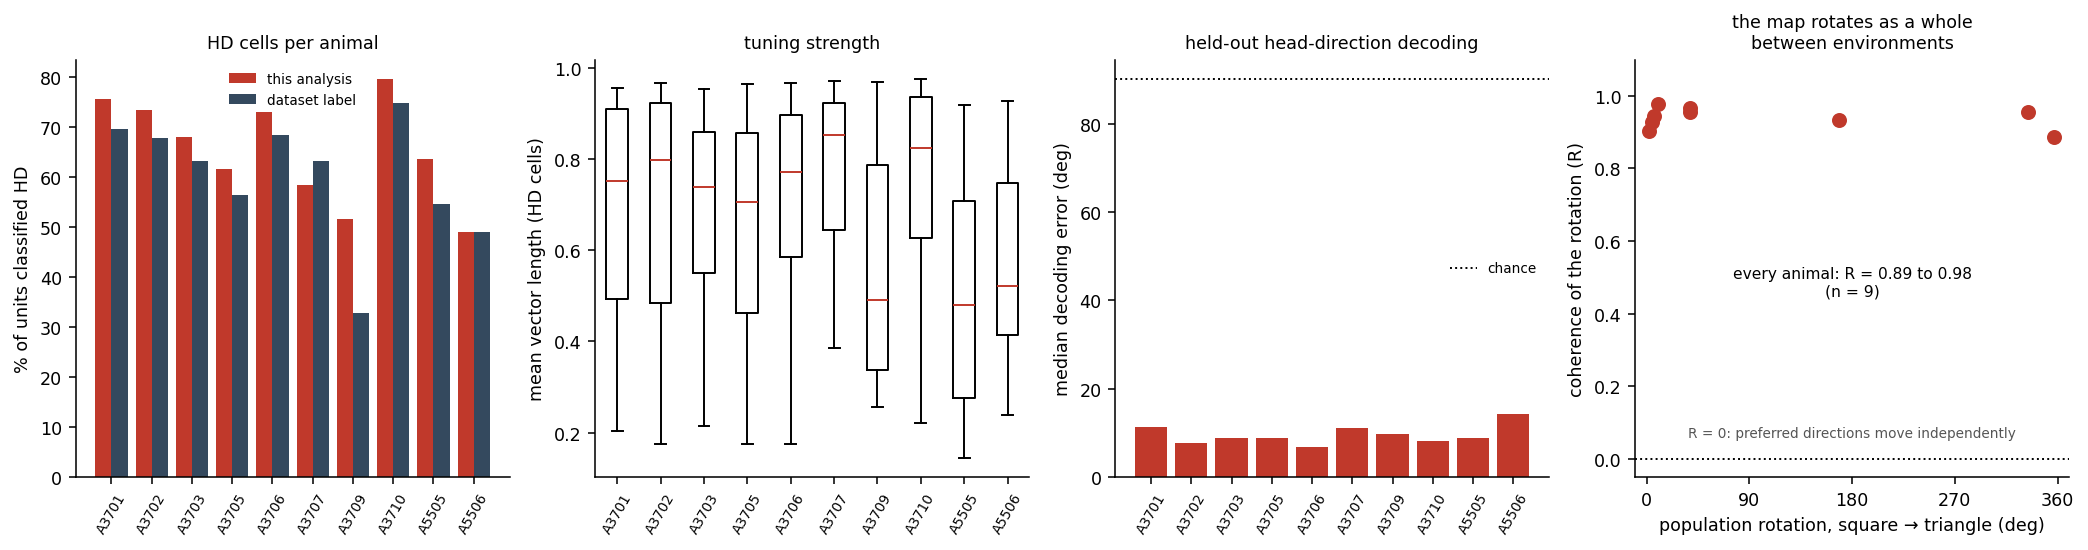

subject  units  HD cells  % HD  HD (authors)  median MVL  decode err (deg)  rotation (deg)
  A3701    102        77    75            71        0.75              11.4            38.0
  A3702     90        66    73            61        0.80               7.7             2.0
  A3703    103        70    68            65        0.74               8.9           334.0
  A3705    117        72    62            66        0.71               8.9            10.0
  A3706    126        92    73            86        0.77               6.8           169.0
  A3707    185       108    58           117        0.85              11.2            38.0
  A3709     64        33    52            21        0.49               9.6             NaN
  A3710    107        85    79            80        0.82               8.1             5.0
  A5505     55        35    64            30        0.48               8.8             6.0
  A5506     49        24    49            24        0.52              14.2           357.0

In [17]:
names = list(R)
short = [s.split("_")[0].replace("sub-", "") for s in names]
xx = np.arange(len(names))

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
ax = axes[0]
ax.bar(xx - 0.2, [100 * R[s]["is_hd"].mean() for s in names], 0.4, color=HDC,
       label="this analysis")
ax.bar(xx + 0.2, [100 * R[s]["is_hd_author"].mean() for s in names], 0.4, color="#34495e",
       label="dataset label")
ax.set_xticks(xx); ax.set_xticklabels(short, rotation=60, fontsize=7)
ax.set_ylabel("% of units classified HD"); ax.legend(fontsize=7, frameon=False)
ax.set_title("HD cells per animal", fontsize=9)

ax = axes[1]
ax.boxplot([R[s]["mvl"][R[s]["is_hd"]] for s in names], showfliers=False,
           medianprops=dict(color=HDC), tick_labels=short)
ax.tick_params(axis="x", rotation=60, labelsize=7)
ax.set_ylabel("mean vector length (HD cells)")
ax.set_title("tuning strength", fontsize=9)

ax = axes[2]
ax.bar(xx, [np.median(R[s]["decode_err"]) for s in names], color=HDC)
ax.axhline(90, color="k", ls=":", lw=1, label="chance")
ax.set_xticks(xx); ax.set_xticklabels(short, rotation=60, fontsize=7)
ax.set_ylabel("median decoding error (deg)"); ax.legend(fontsize=7, frameon=False)
ax.set_title("held-out head-direction decoding", fontsize=9)

ax = axes[3]
has = [s for s in names if R[s]["cross"] is not None]
rot = [np.degrees(R[s]["cross"]["rotation"]) for s in has]
coh = [R[s]["cross"]["R"] for s in has]
ax.scatter(rot, coh, s=45, c=HDC)
ax.axhline(0, color="k", ls=":", lw=1)
ax.text(180, 0.06, "R = 0: preferred directions move independently",
        ha="center", fontsize=7, color="#555555")
ax.text(180, 0.45, "every animal: R = %.2f to %.2f\n(n = %d)"
        % (min(coh), max(coh), len(coh)), ha="center", fontsize=8)
ax.set_xlim(-10, 370); ax.set_ylim(-0.05, 1.1); ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xlabel("population rotation, square → triangle (deg)")
ax.set_ylabel("coherence of the rotation (R)")
ax.set_title("the map rotates as a whole\nbetween environments", fontsize=9)
fig.tight_layout()
save_fig(fig, "fig09_across_animals.png")

summary = pd.DataFrame({
    "subject": [R[s]["subject"] for s in names],
    "units": [len(R[s]["mvl"]) for s in names],
    "HD cells": [int(R[s]["is_hd"].sum()) for s in names],
    "% HD": [round(100 * R[s]["is_hd"].mean()) for s in names],
    "HD (authors)": [int(R[s]["is_hd_author"].sum()) for s in names],
    "median MVL": [round(float(np.median(R[s]["mvl"][R[s]["is_hd"]])), 2) for s in names],
    "decode err (deg)": [round(float(np.median(R[s]["decode_err"])), 1) for s in names],
    "rotation (deg)": [None if R[s]["cross"] is None
                       else round(float(np.degrees(R[s]["cross"]["rotation"]))) for s in names],
})
print(summary.to_string(index=False))

## Conclusions

Across ten mice and 998 postsubicular units, 66% are head-direction cells by a
conservative conjunctive criterion (mean vector length above the 99th
percentile of a pooled circular-shift null, per-cell shuffle p < 0.01, and
split-half tuning correlation above 0.5). Their tuning is sharp, with a median
full width at half maximum near 36 degrees, and it is strong: median mean
vector length 0.76 and median directional information 1.5 bits per spike,
against 0.09 and 0.04 for the rest of the population. This recovers 93% of the
units the dataset's authors independently flagged as HD cells.

The population behaves as a single coherent variable rather than as a set of
independent direction detectors. Preferred directions tile the circle
uniformly; a Bayesian decoder trained on one half of a foraging session
recovers head direction on the held-out half to a median error of about
9 degrees, improving monotonically with ensemble size; when the animal is moved
from a square to a triangular arena the whole map rotates by a common angle
with a circular spread of only about 19 degrees around that rotation; and the
pairwise correlation structure of the HD ensemble during foraging is reproduced
with r = 0.83 during REM and r = 0.85 during non-REM sleep, when no directional
sensory information is available. A Poisson GLM using head direction as its
only covariate reaches a median held-out pseudo-R² of 0.31 in HD cells against
essentially zero in the remaining units. Splitting the arena into quadrants and
recomputing preferred directions within each shifts them by a median of only
5 degrees, so this is directional coding and not a spatial confound. Taken together these are the properties
expected of a continuous ring attractor whose state is maintained internally
and is only anchored, not created, by sensory landmarks.